# Assignment: Matrix Multiplication Performance with Cython

**Course:** EE2703 - Applied Programming Laboratory  
**Topic:** Introduction to Cython for Performance Optimization

---

## Learning Objectives

In this assignment, you will:
1. Profile pure Python matrix multiplication code
2. Progressively optimize it using Cython techniques
3. Compare performance against NumPy's optimized implementation
4. Understand when and why to use Cython

## Instructions

1. **Complete all sections** marked with `# YOUR CODE HERE`
2. **Run all cells in order** - Use "Restart & Run All" before submission
3. **Fill in the analysis sections** with your observations
4. **Submit this notebook** with all outputs visible

---

## Setup

If you are running this on the JupyterLab server https://jup.dev.iitm.ac.in/ all the required modules are already present and you should not need anything new installed.  The final code will be evaluated on this machine, so in case you use any modules not present there your code may not work.  You can temporarily work on a Google colab notebook if you find that comfortable, but keep in mind that final evaluation will be on the Jup server.

If you are running it on your own system, you *may* need to install the following packages:

```bash
pip install setuptools cython numpy pandas matplotlib jupyter
```

The template code has been written assuming you will use a notebook that supports the `%%cython` magic commands.  Hence, a plain Python script will **NOT** be acceptable.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load Cython magic
%load_ext cython

print("Setup complete!")

Setup complete!


## Part 1: Baseline Python Implementation

Implement a simple matrix multiplication function in pure Python using nested loops. This should be similar to what you did in your first assignment.

**Requirements:**
- Use three nested loops (i, j, k)
- No NumPy or other libraries
- Handle matrices as lists of lists

In [2]:
def matmul_python(A, B):
    """
    Pure Python matrix multiplication.
    
    Args:
        A: Matrix of size (m, n) as list of lists
        B: Matrix of size (n, p) as list of lists
    
    Returns:
        Result matrix of size (m, p) as list of lists
    """
    # YOUR CODE HERE
    m=len(A)
    n=len(B)
    if m==0 and n==0:
        return []
    p=len(B[0])
    new_mat = []
    for i in range(m):
        l=[0]*p
        for j in range(p):
            sum=0
            for k in range(n):
                sum+=A[i][k]*B[k][j]       
            l[j]=sum
        new_mat.append(l)
    return new_mat
    
        

### Test the Implementation

In [3]:
# Small test to verify correctness
A_test = [[1, 2], [3, 4]]
B_test = [[5, 6], [7, 8]]
C_test = matmul_python(A_test, B_test)

print("Test multiplication:")
print(f"A = {A_test}")
print(f"B = {B_test}")
print(f"C = {C_test}")
print(f"\nExpected: [[19, 22], [43, 50]]")

# Verify with NumPy
import numpy as np
A_np = np.array(A_test)
B_np = np.array(B_test)
C_np = A_np @ B_np
print(f"NumPy result: {C_np.tolist()}")

Test multiplication:
A = [[1, 2], [3, 4]]
B = [[5, 6], [7, 8]]
C = [[19, 22], [43, 50]]

Expected: [[19, 22], [43, 50]]
NumPy result: [[19, 22], [43, 50]]


### Timing Function

We'll use this helper function to time all implementations.

In [4]:
import time
def time_matmul(func, A, B, name="", runs=3):
    """
    Time a matrix multiplication function.
    
    Args:
        func: Function to time
        A, B: Input matrices
        name: Name for display
        runs: Number of runs to average
    
    Returns:
        Average time in seconds
    """
    times = []
    for _ in range(runs):
        start = time.time()
        result = func(A, B)
        elapsed = time.time() - start
        times.append(elapsed)
    
    avg_time = sum(times) / len(times)
    print(f"{name:30s}: {avg_time:.4f} seconds")
    return avg_time

### Benchmark Python Implementation

Test with different matrix sizes.

In [5]:
# Create test matrices of different sizes
sizes = [64, 128, 256, 512]
python_times = []

print("Benchmarking Pure Python Implementation")
print("=" * 50)

for size in sizes:
    # Create random matrices as lists
    A = [[float(np.random.rand()) for _ in range(size)] for _ in range(size)]
    B = [[float(np.random.rand()) for _ in range(size)] for _ in range(size)]
    
    print(f"\nSize {size}x{size}:")
    t = time_matmul(matmul_python, A, B, f"Python {size}x{size}")
    python_times.append(t)

Benchmarking Pure Python Implementation

Size 64x64:
Python 64x64                  : 0.0220 seconds

Size 128x128:
Python 128x128                : 0.1640 seconds

Size 256x256:
Python 256x256                : 1.4317 seconds

Size 512x512:
Python 512x512                : 12.3342 seconds


---

## Part 2: Cython Level 1 - Basic Compilation

In this level, we simply compile the Python code with Cython without any modifications. This gives us a baseline for Cython's improvement.

**Task:** Copy your Python function into the Cython cell below (with `%%cython` magic).

In [6]:
%load_ext Cython

In [7]:

%%cython
def matmul_cython_level1(A, B):
    """
    Level 1: Pure Python code compiled with Cython.
    No optimizations, just basic compilation.
    """
    # YOUR CODE HERE
    m=len(A)
    n=len(B)
    if m==0 and n==0:
        return []
    p=len(B[0])
    new_mat = []
    for i in range(m):
        l=[0]*p
        for j in range(p):
            sum=0
            for k in range(n):
                sum+=A[i][k]*B[k][j]       
            l[j]=sum
        new_mat.append(l)
    return new_mat
    
    
        


### Benchmark Level 1

In [8]:
cython_level1_times = []

print("Benchmarking Cython Level 1 (Basic Compilation)")
print("=" * 50)

for size in sizes:
    A = [[float(np.random.rand()) for _ in range(size)] for _ in range(size)]
    B = [[float(np.random.rand()) for _ in range(size)] for _ in range(size)]
    
    print(f"\nSize {size}x{size}:")
    t = time_matmul(matmul_cython_level1, A, B, f"Cython L1 {size}x{size}")
    cython_level1_times.append(t)
    
    speedup = python_times[sizes.index(size)] / t
    print(f"  Speedup vs Python: {speedup:.2f}x")

Benchmarking Cython Level 1 (Basic Compilation)

Size 64x64:
Cython L1 64x64               : 0.0070 seconds
  Speedup vs Python: 3.13x

Size 128x128:
Cython L1 128x128             : 0.0624 seconds
  Speedup vs Python: 2.63x

Size 256x256:
Cython L1 256x256             : 0.6587 seconds
  Speedup vs Python: 2.17x

Size 512x512:
Cython L1 512x512             : 5.8392 seconds
  Speedup vs Python: 2.11x


---

## Part 3: Cython Level 2 - Type Declarations

Now we add static type declarations to help Cython generate efficient C code.

**Key optimizations:**
- Use `cdef` to declare loop variables as integers
- Declare matrix dimensions as integers
- Use `cdef` for the accumulator variable

**Task:** Add type declarations to your code.

In [9]:
%load_ext cython

The cython extension is already loaded. To reload it, use:
  %reload_ext cython


In [10]:
%%cython

def matmul_cython_level2(A, B):
    """
    Level 2: Add static type declarations.
    This allows Cython to generate more efficient C code.
    """
    # YOUR CODE HERE
    cdef int m,n,p,i,j,k
    cdef float sum,x,y
    m=len(A)
    n=len(B)
    if m==0 and n==0:
        return []
    p=len(B[0])
    new_mat = []
    for i in range(m):
        l=[0]*p
        for j in range(p):
            sum=0
            for k in range(n):
                x=A[i][k]
                y=B[k][j]
                sum+=x*y       
            l[j]=sum
        new_mat.append(l)
    return new_mat
    


### Benchmark Level 2

In [11]:
cython_level2_times = []

print("Benchmarking Cython Level 2 (Type Declarations)")
print("=" * 50)

for size in sizes:
    A = [[float(np.random.rand()) for _ in range(size)] for _ in range(size)]
    B = [[float(np.random.rand()) for _ in range(size)] for _ in range(size)]
    
    print(f"\nSize {size}x{size}:")
    t = time_matmul(matmul_cython_level2, A, B, f"Cython L2 {size}x{size}")
    cython_level2_times.append(t)
    
    speedup = python_times[sizes.index(size)] / t
    print(f"  Speedup vs Python: {speedup:.2f}x")
    print(f"  Speedup vs Level 1: {cython_level1_times[sizes.index(size)] / t:.2f}x")

Benchmarking Cython Level 2 (Type Declarations)

Size 64x64:
Cython L2 64x64               : 0.0039 seconds
  Speedup vs Python: 5.70x
  Speedup vs Level 1: 1.82x

Size 128x128:
Cython L2 128x128             : 0.0320 seconds
  Speedup vs Python: 5.13x
  Speedup vs Level 1: 1.95x

Size 256x256:
Cython L2 256x256             : 0.3769 seconds
  Speedup vs Python: 3.80x
  Speedup vs Level 1: 1.75x

Size 512x512:
Cython L2 512x512             : 3.3882 seconds
  Speedup vs Python: 3.64x
  Speedup vs Level 1: 1.72x


---

## Part 4: Cython Level 3 - NumPy Arrays with Memory Views

The biggest speedup comes from using NumPy arrays with Cython's memory views. This allows direct access to array data without Python overhead.

**Key optimizations:**
- Accept NumPy arrays as input (not lists)
- Use memory view syntax: `double[:, :]` for 2D arrays
- Add compiler directives to disable safety checks - `boundscheck` and `wraparound` are useful decorators

**Task:** Implement the fully optimized version using memory views.

In [12]:
%%cython
import numpy as np
cimport numpy as np
cimport cython
@cython.boundscheck(False)
@cython.wraparound(False)

def matmul_cython_level3(double[:, :] A, double[:, :] B):
    """
    Level 3: Use NumPy arrays with memory views for maximum speed.
    This provides direct access to array data without Python overhead.
    """
    cdef int i, j, k, m, n, p
    cdef double sum
    m = A.shape[0]
    n= A.shape[1]
    p = B.shape[1]
    cdef double[:, :] res = np.zeros((m, p), dtype=np.float64)
    for i in range(m):
        for j in range(p):
            sum = 0.0
            for k in range(n):
                sum += A[i,k] * B[k,j]
            res[i,j]=sum
    return np.asarray(res)
    


### Benchmark Level 3

In [13]:
cython_level3_times = []

print("Benchmarking Cython Level 3 (Memory Views)")
print("=" * 50)

for size in sizes:
    # Create NumPy arrays for this version
    A_np = np.random.rand(size, size)
    B_np = np.random.rand(size, size)
    
    print(f"\nSize {size}x{size}:")
    t = time_matmul(matmul_cython_level3, A_np, B_np, f"Cython L3 {size}x{size}")
    cython_level3_times.append(t)
    
    speedup = python_times[sizes.index(size)] / t
    print(f"  Speedup vs Python: {speedup:.2f}x")
    print(f"  Speedup vs Level 2: {cython_level2_times[sizes.index(size)] / t:.2f}x")

Benchmarking Cython Level 3 (Memory Views)

Size 64x64:
Cython L3 64x64               : 0.0003 seconds
  Speedup vs Python: 74.12x
  Speedup vs Level 2: 13.01x

Size 128x128:
Cython L3 128x128             : 0.0024 seconds
  Speedup vs Python: 67.76x
  Speedup vs Level 2: 13.22x

Size 256x256:
Cython L3 256x256             : 0.0184 seconds
  Speedup vs Python: 77.99x
  Speedup vs Level 2: 20.53x

Size 512x512:
Cython L3 512x512             : 0.4182 seconds
  Speedup vs Python: 29.49x
  Speedup vs Level 2: 8.10x


---

## Part 5: NumPy Comparison

Compare all your implementations with NumPy's highly optimized matrix multiplication.

NumPy uses BLAS (Basic Linear Algebra Subprograms), which are highly optimized, often in assembly language, and may use SIMD instructions.

In [14]:
def matmul_numpy(A, B):
    """NumPy matrix multiplication using @ operator."""
    return A @ B

numpy_times = []

print("Benchmarking NumPy Implementation")
print("=" * 50)

for size in sizes:
    A_np = np.random.rand(size, size)
    B_np = np.random.rand(size, size)
    
    print(f"\nSize {size}x{size}:")
    t = time_matmul(matmul_numpy, A_np, B_np, f"NumPy {size}x{size}")
    numpy_times.append(t)
    
    speedup = python_times[sizes.index(size)] / t
    print(f"  Speedup vs Python: {speedup:.2f}x")

Benchmarking NumPy Implementation

Size 64x64:
NumPy 64x64                   : 0.0001 seconds
  Speedup vs Python: 197.31x

Size 128x128:
NumPy 128x128                 : 0.0054 seconds
  Speedup vs Python: 30.58x

Size 256x256:
NumPy 256x256                 : 0.0006 seconds
  Speedup vs Python: 2530.53x

Size 512x512:
NumPy 512x512                 : 0.0084 seconds
  Speedup vs Python: 1471.39x


---

## Part 6: Analysis and Reflection

### Summary Table

Create a comprehensive comparison table.

In [15]:
# Create summary DataFrame
results = {
    'Size': [f"{s}x{s}" for s in sizes],
    'Python (s)': python_times,
    'Cython L1 (s)': cython_level1_times,
    'Cython L2 (s)': cython_level2_times,
    'Cython L3 (s)': cython_level3_times,
    'NumPy (s)': numpy_times,
}

df = pd.DataFrame(results)

# Add speedup columns
df['Speedup L1'] = df['Python (s)'] / df['Cython L1 (s)']
df['Speedup L2'] = df['Python (s)'] / df['Cython L2 (s)']
df['Speedup L3'] = df['Python (s)'] / df['Cython L3 (s)']
df['Speedup NumPy'] = df['Python (s)'] / df['NumPy (s)']

print("\n" + "=" * 80)
print("TIMING RESULTS (seconds)")
print("=" * 80)
print(df[['Size', 'Python (s)', 'Cython L1 (s)', 'Cython L2 (s)', 'Cython L3 (s)', 'NumPy (s)']].to_string(index=False))

print("\n" + "=" * 80)
print("SPEEDUP FACTORS (vs Pure Python)")
print("=" * 80)
print(df[['Size', 'Speedup L1', 'Speedup L2', 'Speedup L3', 'Speedup NumPy']].to_string(index=False))


TIMING RESULTS (seconds)
   Size  Python (s)  Cython L1 (s)  Cython L2 (s)  Cython L3 (s)  NumPy (s)
  64x64    0.022000       0.007037       0.003861       0.000297   0.000112
128x128    0.163991       0.062414       0.031987       0.002420   0.005363
256x256    1.431691       0.658716       0.376918       0.018358   0.000566
512x512   12.334207       5.839158       3.388213       0.418186   0.008383

SPEEDUP FACTORS (vs Pure Python)
   Size  Speedup L1  Speedup L2  Speedup L3  Speedup NumPy
  64x64    3.126391    5.697878   74.115127     197.305773
128x128    2.627460    5.126834   67.757569      30.580627
256x256    2.173457    3.798421   77.988718    2530.530693
512x512    2.112326    3.640328   29.494523    1471.385176


### Visualization

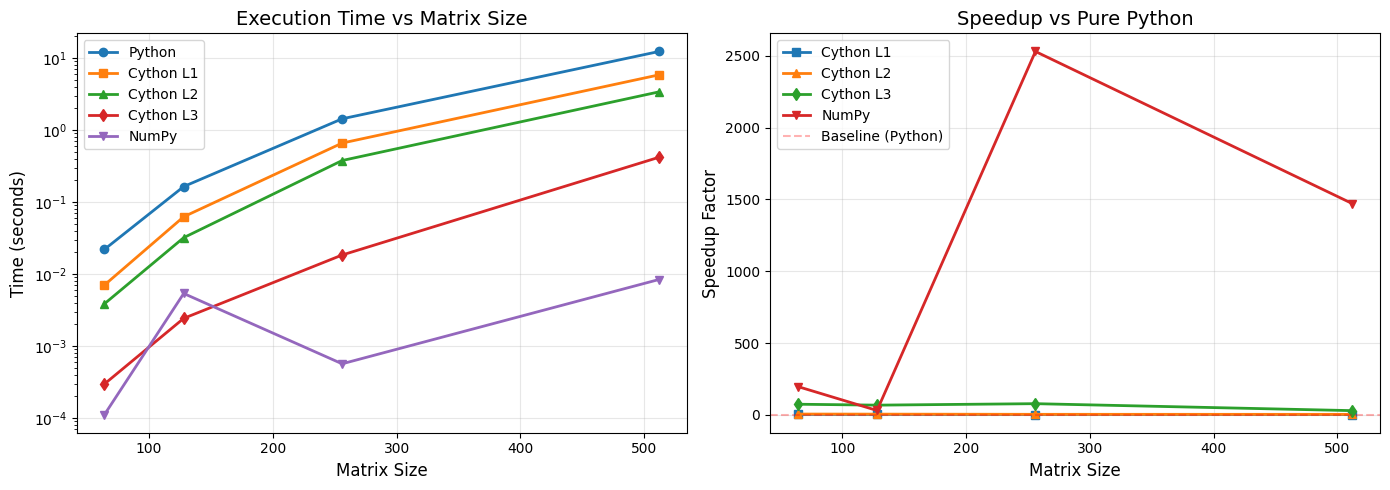

Figure saved as 'matmul_performance.png'


In [16]:
# Plot timing comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Absolute timing
ax1.plot(sizes, python_times, 'o-', label='Python', linewidth=2)
ax1.plot(sizes, cython_level1_times, 's-', label='Cython L1', linewidth=2)
ax1.plot(sizes, cython_level2_times, '^-', label='Cython L2', linewidth=2)
ax1.plot(sizes, cython_level3_times, 'd-', label='Cython L3', linewidth=2)
ax1.plot(sizes, numpy_times, 'v-', label='NumPy', linewidth=2)
ax1.set_xlabel('Matrix Size', fontsize=12)
ax1.set_ylabel('Time (seconds)', fontsize=12)
ax1.set_title('Execution Time vs Matrix Size', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# Speedup comparison
ax2.plot(sizes, df['Speedup L1'], 's-', label='Cython L1', linewidth=2)
ax2.plot(sizes, df['Speedup L2'], '^-', label='Cython L2', linewidth=2)
ax2.plot(sizes, df['Speedup L3'], 'd-', label='Cython L3', linewidth=2)
ax2.plot(sizes, df['Speedup NumPy'], 'v-', label='NumPy', linewidth=2)
ax2.axhline(y=1, color='r', linestyle='--', alpha=0.3, label='Baseline (Python)')
ax2.set_xlabel('Matrix Size', fontsize=12)
ax2.set_ylabel('Speedup Factor', fontsize=12)
ax2.set_title('Speedup vs Pure Python', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('matmul_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved as 'matmul_performance.png'")

### Reflection Questions

Answer the following questions based on your results. Write 2-3 sentences for each.

#### Q1: What was the speedup from Level 1 (basic Cython) compared to pure Python?

**Your Answer:**

2-3x speedup.
Even adding the cython line before executing it makes it sun faster because we now direct the program to convert the given python code into C code. 
It's not executed line by line like bytecode in python, but rather compiled in machine code like C is, along with all the optimisations that the C compiler offers, that otherwise won't be available in pure Python. 

#### Q2: What additional speedup did you get from adding type declarations (Level 2)?

**Your Answer:**

We get a little less than 2x additional speedup from level 2 code. This comes from using cdef statements (that is, statically typed variables). It saves type-checking overhead during runtime.

#### Q3: Why did Level 3 (memory views) provide the biggest speedup?

**Your Answer:**

Compared to level 2, we get at least 8x relative speedup with numpy and memoryviews.
1. Memoryviews enables us to directly access C memory, not just python objects. So A[i,j] is a direct pointer to the i,j position in our 2D array, no python API calls needed. That saves on a lot of overhead.
2. Numpy arrays are directly converted to C arrays, so that memoryviews can actually work.

#### Q4: How does your best Cython implementation compare to NumPy? Why is NumPy still faster?

**Your Answer:**

Numpy utilises multiple optimisations-
1. BLAS libraries - These are written in low level languages for extremely fast linear and matrix computations.
2. Cache optimisation - Makes data accessibility more efficient using caching and memory alignment.
3. SIMD instructions - One CPU core can perform same instructions on multiple data at the same time (vector registers that hold multiple data at the same time).
4. Multithreading - Numpy also takes advantage of multithreading, which is, running different tasks simultaneously on multiple cores.
Also, numpy uses highly optimised C and assembly code, which is why is so much faster.

#### Q5: When would you use Cython instead of NumPy for numerical computing?

**Your Answer:**

Say we want to write our own math logic for which numpy doesn't have built in code, or we want a lot of control over how our memory is accessed and manipulated, we would use cython. Cython helps build highly customisable code.

#### Q6: What are the trade-offs of using Cython? (Consider development time, debugging, portability)

**Your Answer:**

[Write your answer here - discuss compilation overhead, debugging difficulty, C dependency, but gains in performance]
If you use cython with python objects, you have to constantly perform conversions between C data types and python objects. Also, C API calls also take up some time. 
Since we do not know what the python code is getting converted into, it's difficult to debug cython code as well. 
Executing cython requires  additional dependencies such as C compilers.
However, we can clearly see gains in performance after doing some optimisations like static typing, memoryviews and so on.

---

## Submission Checklist

Before submitting, verify:

- [.] All code cells have been executed (outputs are visible)
- [.] All four Cython levels are implemented
- [.] Timing results are present for all test cases
- [.] Summary table is generated
- [.] Visualization is displayed
- [.] All six reflection questions are answered
- [.] Used "Restart & Run All" before submission

**Submit this notebook (.ipynb file) with all outputs visible.**